# 📊 30-Day Data Analytics Internship Tasks

**By Keerthan MS**
*B.Tech Computer Science & Engineering | Data Analytics Intern at ApexPlanet*

📫 **Let's Connect:**
* **Email:** keerthanms792004@gmail.com
* **LinkedIn:** www.linkedin.com/in/keerthan-ms-697368266
* **GitHub:** https://github.com/keerthan-ms/apexplanet-data-analytics/tree/main

---

## 🚀 Project Overview
This repository contains my progress, code, and final deliverables for the 30-Day Data Analytics Internship with ApexPlanet Software Pvt. Ltd.

In [1]:
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("customer_acquisition_data.csv")

# Display the first 5 rows to make sure it loaded correctly
df.head()

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419


In [4]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv("customer_acquisition_data.csv")
print("--- Initial Data Check ---")
print(df.info())

# 2. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Handle outliers using IQR (Interquartile Range) for Revenue
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_cleaned = df[(df['revenue'] >= lower_bound) & (df['revenue'] <= upper_bound)].copy()

print(f"\nOriginal rows: {len(df)}, Cleaned rows (after IQR): {len(df_cleaned)}")

# 4. Save the cleaned dataset locally
df_cleaned.to_csv("cleaned_customer_acquisition_data.csv", index=False)
print("\nCleaned dataset saved successfully!")

--- Initial Data Check ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      800 non-null    int64  
 1   channel          800 non-null    object 
 2   cost             800 non-null    float64
 3   conversion_rate  800 non-null    float64
 4   revenue          800 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 31.4+ KB
None

--- Missing Values ---
customer_id        0
channel            0
cost               0
conversion_rate    0
revenue            0
dtype: int64

Original rows: 800, Cleaned rows (after IQR): 800

Cleaned dataset saved successfully!


--- Statistical Summary ---


,customer_id,cost,conversion_rate,revenue
count,800.0000,800.000000,800.000000,800.000000
mean,400.5000,13.148052,0.086305,2769.151250
std,231.0844,9.922337,0.059611,1259.543706
min,1.0000,5.246263,0.016341,500.000000
25%,200.7500,5.246263,0.043822,1694.000000
50%,400.5000,8.320327,0.043822,2764.000000
75%,600.2500,9.546326,0.123145,3824.250000
max,800.0000,30.450327,0.167592,4998.000000


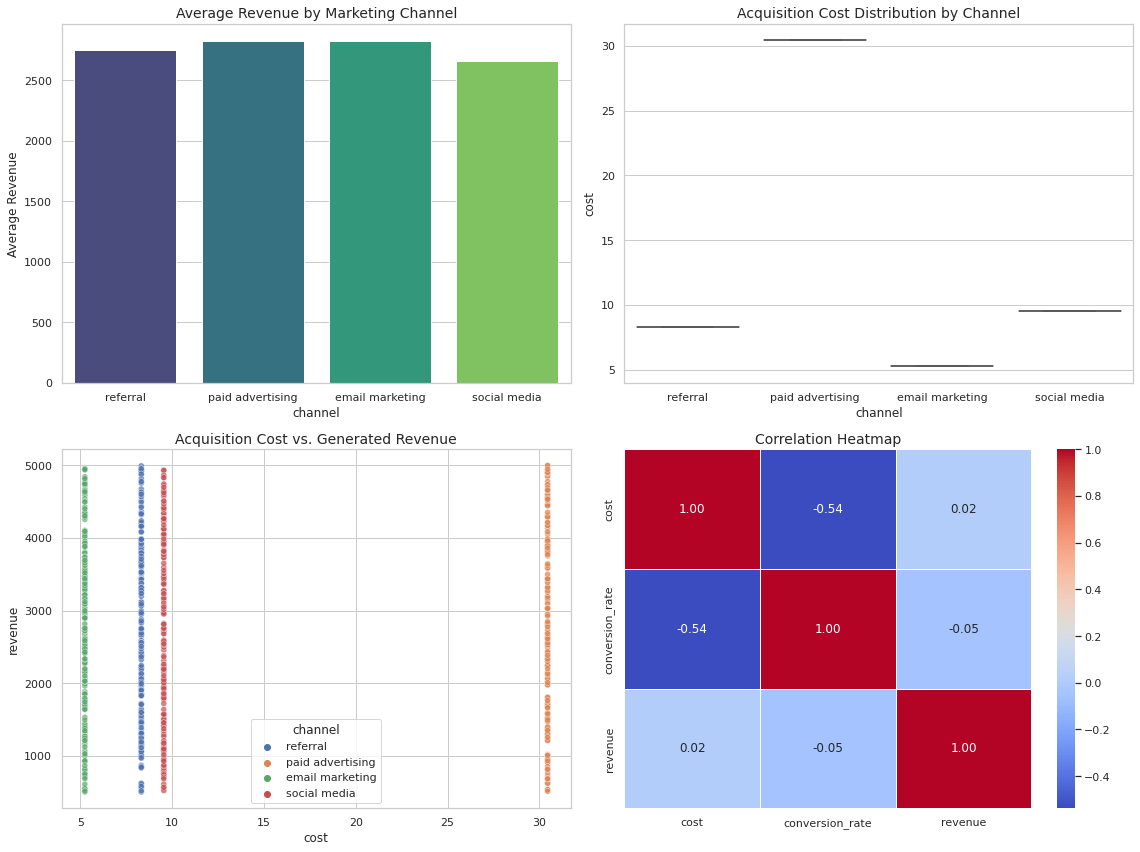

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Generate Statistical Summary
print("--- Statistical Summary ---")
display(df_cleaned.describe())

# Set up the visual canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 2. Bar Chart: Average Revenue by Marketing Channel
plt.subplot(2, 2, 1)
# Changed errorbar=None to ci=None for compatibility with older seaborn versions
sns.barplot(data=df_cleaned, x='channel', y='revenue', ci=None, palette='viridis')
plt.title('Average Revenue by Marketing Channel', fontsize=14)
plt.ylabel('Average Revenue')

# 3. Boxplot: Acquisition Cost by Channel
plt.subplot(2, 2, 2)
sns.boxplot(data=df_cleaned, x='channel', y='cost', palette='Set2')
plt.title('Acquisition Cost Distribution by Channel', fontsize=14)

# 4. Scatter Plot: Cost vs Revenue
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_cleaned, x='cost', y='revenue', hue='channel', alpha=0.7)
plt.title('Acquisition Cost vs. Generated Revenue', fontsize=14)

# 5. Heatmap: Correlation Matrix
plt.subplot(2, 2, 4)
# Filter for only numbers and drop the irrelevant customer_id
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).drop(columns=['customer_id'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)

# Show the plots!
plt.tight_layout()
plt.show()

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; padding: 25px; background-color: #f4f7f6; border-radius: 12px; border: 1px solid #dce1e3;">
    <h2 style="color: #2c3e50; border-bottom: 3px solid #3498db; padding-bottom: 10px; margin-top: 0;">🚀 Exploratory Data Analysis: Top 5 Insights</h2>

<div style="background: white; padding: 15px; margin-top: 15px; border-left: 5px solid #3498db; border-radius: 6px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
        <h4 style="margin: 0; color: #2980b9;">1. Uniform Revenue Across Channels (Bar Chart)</h4>
        <p style="margin: 5px 0 0 0; color: #555; font-size: 14px;">The average revenue generated per customer is surprisingly consistent across all four marketing channels, hovering steadily around the 2,500 to 2,800 range. No single channel brings in drastically higher-spending customers.</p>
    </div>

<div style="background: white; padding: 15px; margin-top: 15px; border-left: 5px solid #e74c3c; border-radius: 6px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
        <h4 style="margin: 0; color: #c0392b;">2. Fixed and Disparate Costs (Boxplot)</h4>
        <p style="margin: 5px 0 0 0; color: #555; font-size: 14px;">Acquisition costs are fixed at very specific price points for each channel, with zero variance. Paid Advertising is by far the most expensive at over 30 per acquisition, while Email Marketing is the cheapest at just over 5.</p>
    </div>

<div style="background: white; padding: 15px; margin-top: 15px; border-left: 5px solid #f39c12; border-radius: 6px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
        <h4 style="margin: 0; color: #d35400;">3. Cost Does Not Equal Revenue (Scatter Plot & Heatmap)</h4>
        <p style="margin: 5px 0 0 0; color: #555; font-size: 14px;">There is virtually no correlation (0.02) between the acquisition cost and the revenue generated. Spending 30 on a paid ad does not result in a higher-value customer than spending 5 on an email campaign.</p>
    </div>

<div style="background: white; padding: 15px; margin-top: 15px; border-left: 5px solid #9b59b6; border-radius: 6px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
        <h4 style="margin: 0; color: #8e44ad;">4. Inverse Relationship Between Cost and Conversion (Heatmap)</h4>
        <p style="margin: 5px 0 0 0; color: #555; font-size: 14px;">There is a moderate negative correlation (-0.54) between cost and conversion rate. This indicates that the most expensive channels (like paid advertising) actually yield lower conversion rates compared to the cheaper channels.</p>
    </div>

<div style="background: white; padding: 15px; margin-top: 15px; border-left: 5px solid #2ecc71; border-radius: 6px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
        <h4 style="margin: 0; color: #27ae60;">5. Most Efficient Marketing Channel</h4>
        <p style="margin: 5px 0 0 0; color: #555; font-size: 14px;">Combining these findings, Email Marketing stands out as the most highly optimized channel. It has the lowest acquisition cost but still yields competitive, high-tier average revenue per customer.</p>
    </div>
</div>